# Streaming Hidden Markov Model - Demo

This notebook demonstrates the streaming HMM implementation using the `streaming_hmm` module.
We replicate the results from the original notebook to verify the implementation.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from streaming_hmm import run_streaming_hmm

In [2]:
# Configure matplotlib for publication-quality figures
%config InlineBackend.figure_format = "retina"
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

sns.set_palette("colorblind")

## Data Generation

We generate synthetic data from a 3-regime HMM with Gaussian observations.
Each regime has a different mean, and we use high self-transition probabilities (99%).

In [3]:
# Initialize random key
key = jax.random.PRNGKey(314)
key_sample, key_run = jax.random.split(key)

In [4]:
# Define HMM parameters
n_regimes = 3
transition_matrix_diag = jnp.ones(n_regimes) * 0.99
transition_matrix = jnp.ones((n_regimes, n_regimes)) * (1 - transition_matrix_diag) / (n_regimes - 1)
transition_matrix = transition_matrix.at[jnp.diag_indices(n_regimes)].set(transition_matrix_diag)

log_transition_matrix = jnp.log(transition_matrix)
means = jnp.array([-1, 0, 1]) * 2
obs_var = 1.0 ** 2

In [5]:
# Display transition matrix
transition_matrix

Array([[0.99 , 0.005, 0.005],
       [0.005, 0.99 , 0.005],
       [0.005, 0.005, 0.99 ]], dtype=float32)

In [6]:
# Data generation function
def step(state, key):
    key_state, key_noise = jax.random.split(key)
    proba_change = transition_matrix[state]
    state_next = jax.random.choice(key, len(proba_change), p=proba_change)

    err = jax.random.normal(key_noise) * jnp.sqrt(obs_var)
    obs = means[state_next] + err

    return state_next, (state_next, obs)

In [7]:
# Generate observations
state_init = 0
n_steps = 1500
timesteps = jnp.arange(n_steps)

keys = jax.random.split(key_sample, n_steps)
_, (states, obs) = jax.lax.scan(step, state_init, keys)

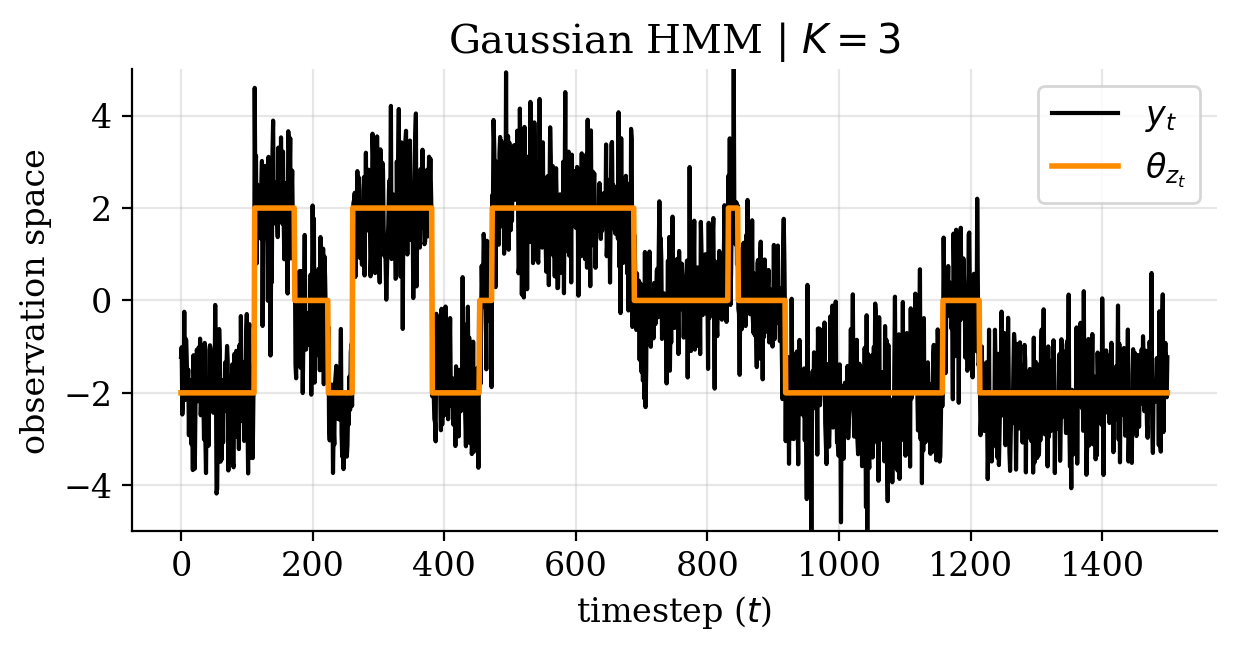

In [8]:
# Plot generated data
plt.plot(obs, c="black", label="$y_t$")
plt.plot(means.at[states].get(), c="darkorange", linewidth=2, label=r"$\theta_{z_t}$")
plt.xlabel("timestep ($t$)")
plt.ylabel("observation space")
plt.title("Gaussian HMM | $K=3$")
plt.legend()
plt.ylim(-5, 5)
plt.grid(alpha=0.3)

In [9]:
# Track regime changes for visualization
regime_changes_ix = jnp.where(jnp.diff(states) != 0)[0]
regime_changes_ix = jnp.insert(regime_changes_ix, 0, 0)
regime_changes_ix = jnp.append(regime_changes_ix, n_steps-1)

colors = sns.color_palette()

---

## Streaming HMM Inference

Now we apply the streaming HMM algorithm to infer both the regime sequence and the regime parameters online.

### Model Specification

We assume:
- Transition probabilities between latent states are known
- We do not know the mean value for each state
- We learn both the regimes and parameters simultaneously

Formally:
$$
\begin{aligned}
    p(s_t \mid s_{t-1}) &= \pi_{s_t,\,s_{t-1}}\\
    p(\Theta \mid s_t) &= {\cal N}(\theta_{s_t} \mid m_0,\,\sigma_0^2)\\
    p(y_t \mid \Theta, s_t) &= {\cal N}(y_t \mid \theta_{s_t},\,\sigma^2)
\end{aligned}
$$
with $\pi_{i,j}$ known for all $i,j$.

### Run Inference

We use beam search with 5 particles to maintain computational tractability.

In [10]:
# Run streaming HMM
n_particles = 5
mean_init = jnp.array([0.0])
var_init = jnp.array([1.0])

key_init, key_eval = jax.random.split(key_run)

bel_final, (hist_lw, hist_mean, hist_variance, hist_forecast), hist_weights = run_streaming_hmm(
    obs=obs,
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    key=key_init,
    n_particles=n_particles,
    var_obs=obs_var,
    mean_init=mean_init,
    var_init=var_init
)

## Results

### Mean Estimates per Regime

Text(0.5, 1.0, 'Learned Mean Parameters for Each Regime')

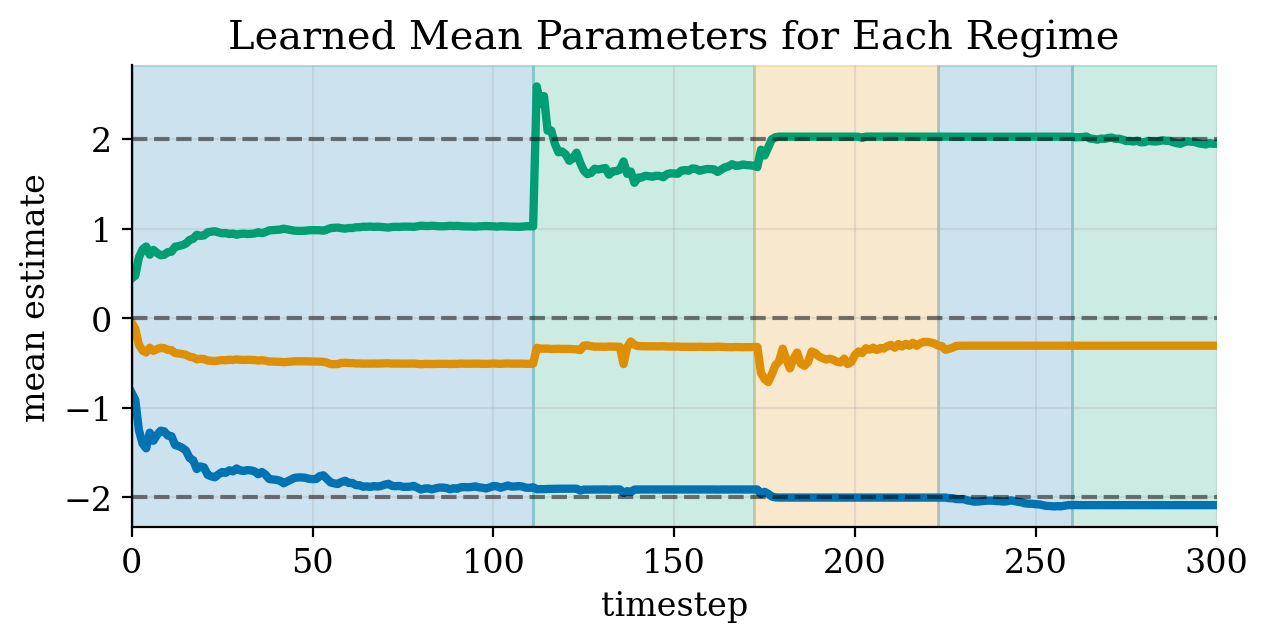

In [11]:
# Compute weighted mean estimates
mean_est = jnp.einsum("ts,tsk...->tk", hist_weights, hist_mean)

plt.plot(mean_est[:, [2,0,1]], linewidth=3)

for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    plt.axvspan(iinit, iend, color=colors[states[iend]], alpha=0.2, linewidth=1)

for mean in means:
    plt.axhline(y=mean, c="black", linestyle="--", alpha=0.5)

plt.ylabel("mean estimate")
plt.xlabel("timestep")
plt.xlim(0, 300)
plt.grid(alpha=0.3)
plt.title("Learned Mean Parameters for Each Regime")

### Regime Probabilities

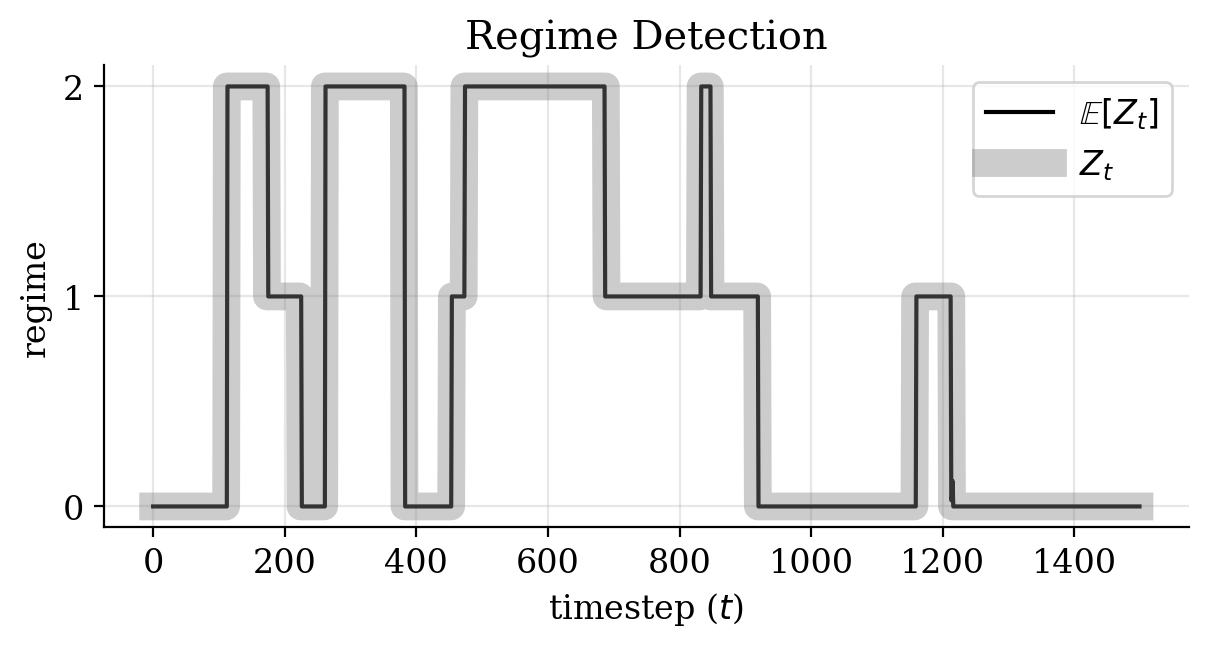

In [12]:
# Compute regime probabilities
hist_regimes_ohe = jax.nn.one_hot(bel_final.regime, n_regimes, axis=0)

proba_regimes = jnp.einsum(
    "kst,ts->tk",
    hist_regimes_ohe[[2,0,1], ...],
    hist_weights
)
path_exp = jnp.einsum("tk,k->t", proba_regimes, jnp.arange(3))

plt.plot(path_exp, c="black", label=r"$\mathbb{E}[Z_t]$")
plt.plot(states, c="gray", linewidth=10, alpha=0.4, label="$Z_t$")
plt.legend()
plt.yticks([0, 1, 2])
plt.xlabel("timestep ($t$)")
plt.ylabel("regime")
plt.title("Regime Detection")
plt.grid(alpha=0.3)

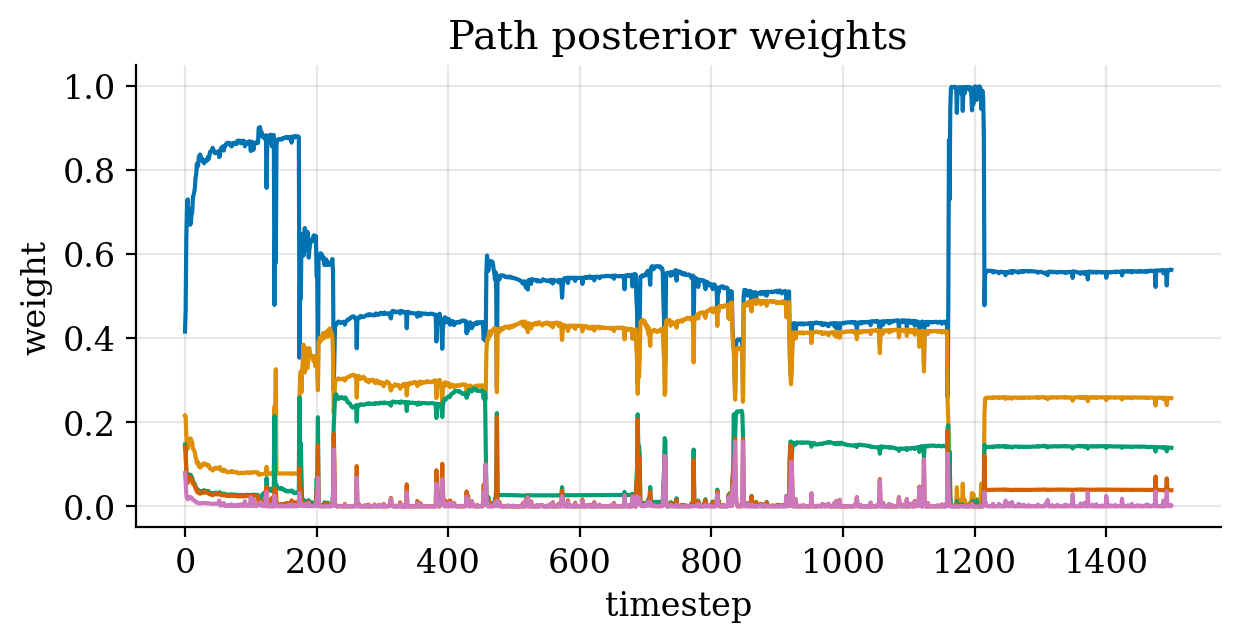

In [13]:
# Particle weights over time
plt.title("Path posterior weights")
plt.plot(hist_weights)
plt.xlabel("timestep")
plt.ylabel("weight")
plt.grid(alpha=0.3)

In [14]:
# Check minimum weight (stability indicator)
print(f"Minimum weight: {hist_weights.min():.6f}")

Minimum weight: 0.000001


### Filtered Estimates

Filtered estimates use all information up to the current time step.

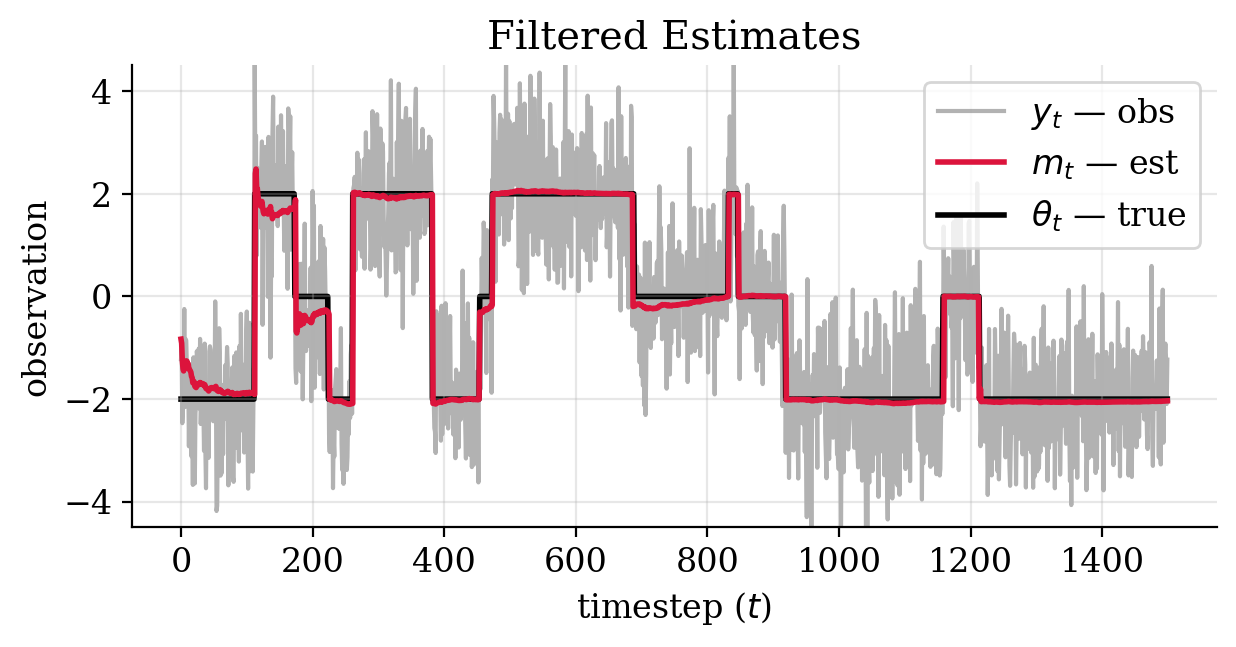

In [15]:
# Compute filtered mean estimate
pmean_est = jnp.einsum(
    "tsk...,kst,ts->t",
    hist_mean,
    hist_regimes_ohe,
    hist_weights
)

plt.plot(obs, c="gray", alpha=0.6, label="$y_t$ — obs", zorder=0)
plt.plot(pmean_est, c="crimson", linewidth=2, label="$m_t$ — est")
plt.plot(means.at[states].get(), c="black", zorder=1, linewidth=2, label=r"$\theta_t$ — true")
plt.legend()
plt.ylim(-4.5, 4.5)
plt.xlabel("timestep ($t$)")
plt.ylabel("observation")
plt.title("Filtered Estimates")
plt.grid(alpha=0.3)

### Forecast Estimates

Forecast estimates predict the next observation before seeing it.

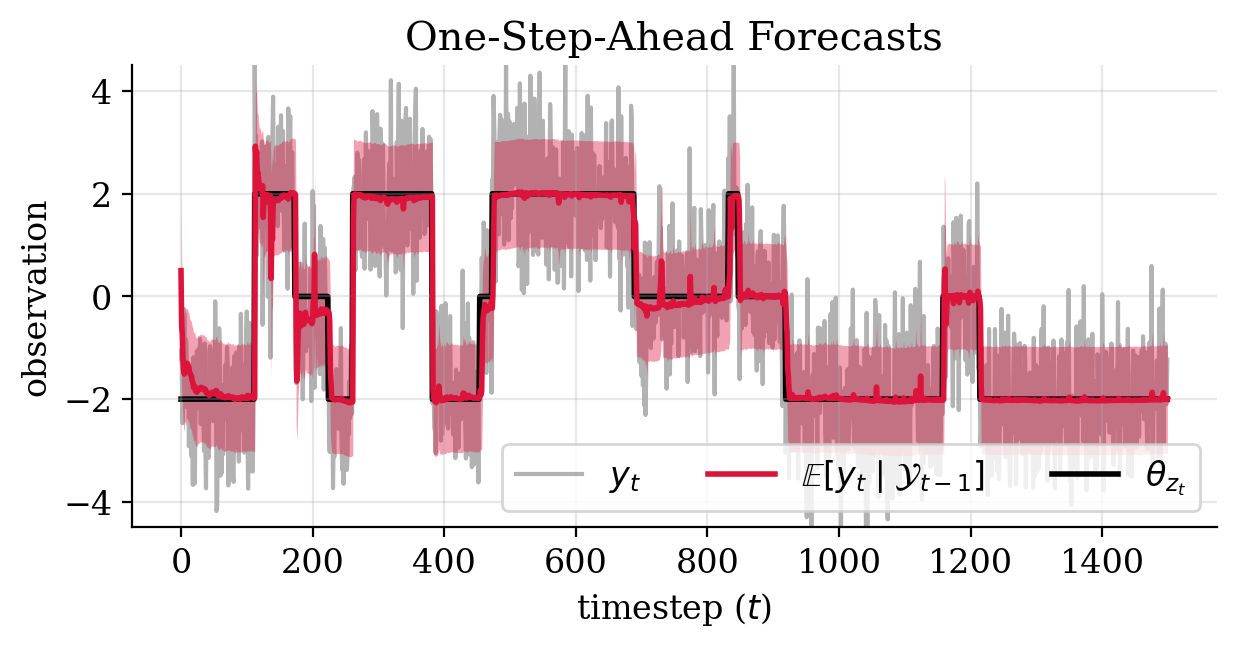

In [16]:
# Compute forecast bounds
lbound = hist_forecast["mean"] - 1 * hist_forecast["stdev_obs"]
ubound = hist_forecast["mean"] + 1 * hist_forecast["stdev_obs"]

plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.4, linewidth=0)
plt.plot(obs, c="gray", alpha=0.6, label="$y_t$", zorder=0)
plt.plot(hist_forecast["mean"], c="crimson", linewidth=2, label=r"$\mathbb{E}[y_{t} \mid {\cal Y}_{t-1}]$")
plt.plot(means.at[states].get(), c="black", zorder=1, linewidth=2, label=r"$\theta_{z_t}$")
plt.legend(ncol=3, loc="lower right")
plt.ylim(-4.5, 4.5)
plt.xlabel("timestep ($t$)")
plt.ylabel("observation")
plt.title("One-Step-Ahead Forecasts")
plt.grid(alpha=0.3)

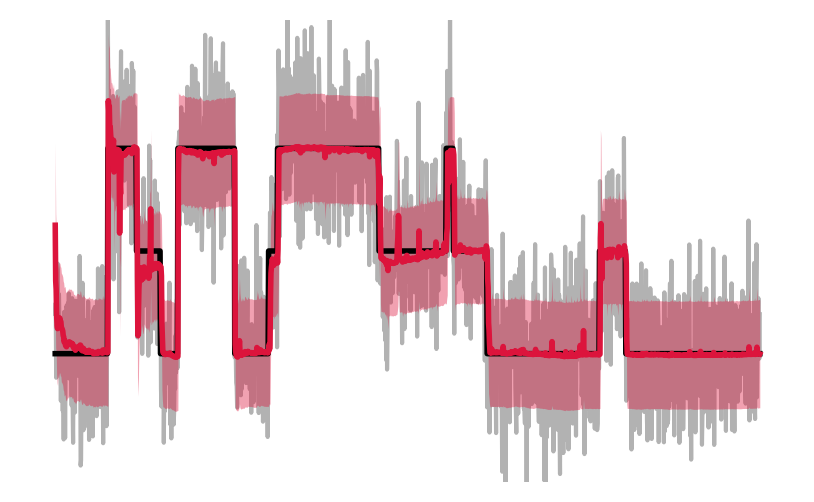

In [26]:
# Compute forecast bounds
fig, ax = plt.subplots(figsize=(5,3))
lbound = hist_forecast["mean"] - 1 * hist_forecast["stdev_obs"]
ubound = hist_forecast["mean"] + 1 * hist_forecast["stdev_obs"]

plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.4, linewidth=0)
plt.plot(obs, c="gray", alpha=0.6, label="$y_t$", zorder=0)
plt.plot(hist_forecast["mean"], c="crimson", linewidth=2, label=r"$\mathbb{E}[y_{t} \mid {\cal Y}_{t-1}]$")
plt.plot(means.at[states].get(), c="black", zorder=1, linewidth=2, label=r"$\theta_{z_t}$")
# plt.legend(ncol=3, loc="lower right")
plt.ylim(-4.5, 4.5)
plt.axis("off")
plt.legend([], frameon=False)
plt.savefig("base.png", dpi=100, bbox_inches="tight")

### Forecast Error Analysis

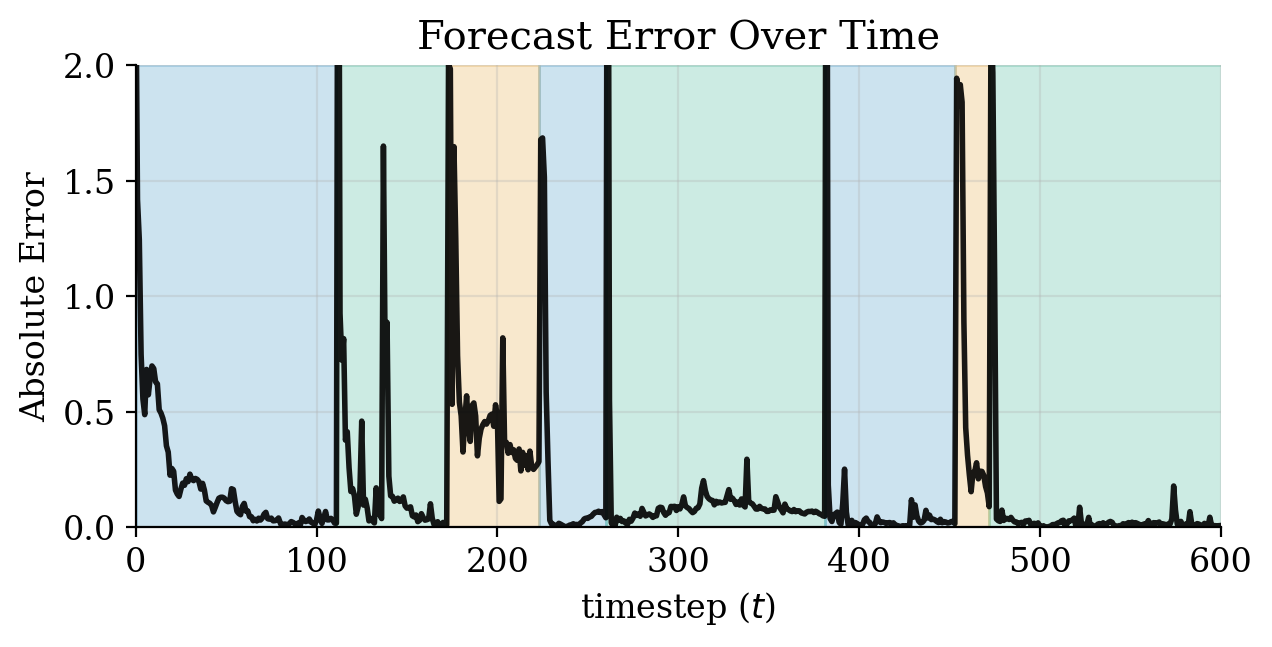

In [17]:
# Compute absolute forecast errors
yhat = hist_forecast["mean"]
ytrue = means.at[states].get()

for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    plt.axvspan(iinit, iend, color=colors[states[iend]], alpha=0.2, linewidth=1)

diff_abs = jnp.abs(yhat - ytrue)
plt.plot(diff_abs, c="black", linewidth=2, alpha=0.9)
plt.ylim(0, 2)
plt.xlim(0, 600)
plt.xlabel("timestep ($t$)")
plt.ylabel("Absolute Error")
plt.title("Forecast Error Over Time")
plt.grid(alpha=0.3)

### Zoomed-in Views

Let's examine forecast performance in specific regions.

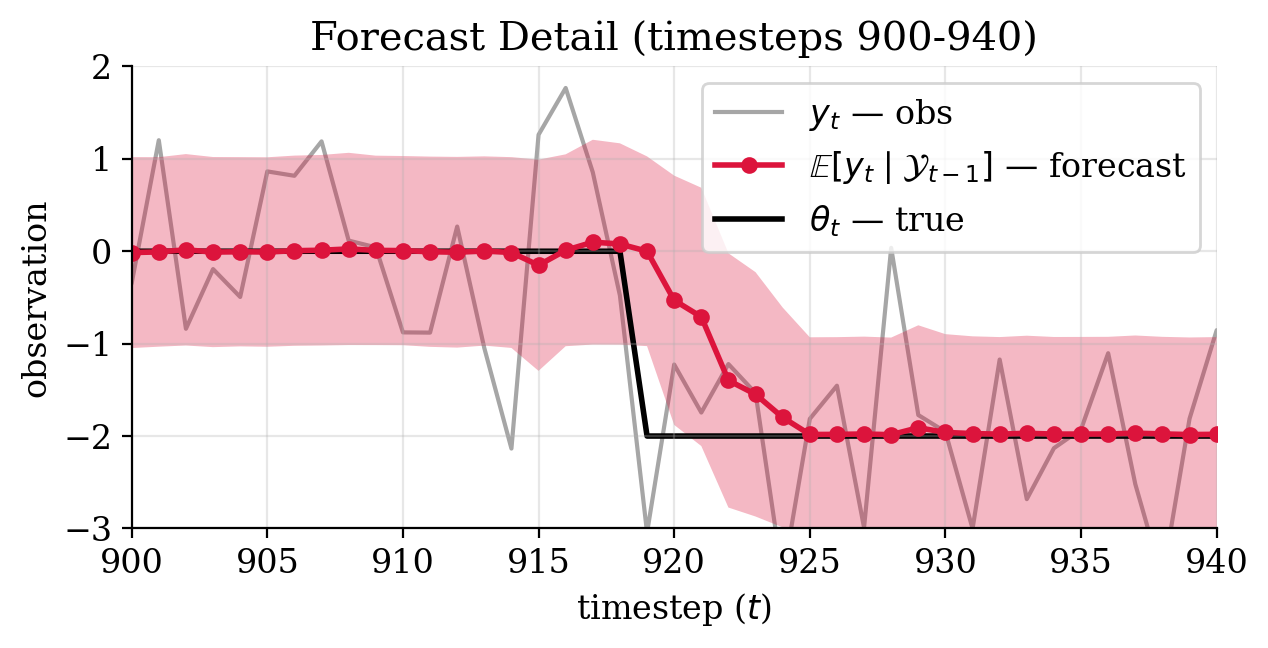

In [18]:
# Region 1: timesteps 900-940
plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.3, linewidth=0)

label_mean = r"$\mathbb{E}[y_{t} \mid {\cal Y}_{t-1}]$ — forecast"
plt.plot(obs, c="gray", alpha=0.7, label="$y_t$ — obs", zorder=0)
plt.plot(hist_forecast["mean"], c="crimson", linewidth=2, label=label_mean, marker="o", markersize=5)
plt.plot(means.at[states].get(), c="black", zorder=1, linewidth=2, label=r"$\theta_t$ — true")

plt.legend()
plt.xlim(900, 940)
plt.ylim(-3, 2)
plt.xlabel("timestep ($t$)")
plt.ylabel("observation")
plt.title("Forecast Detail (timesteps 900-940)")
plt.grid(alpha=0.3)

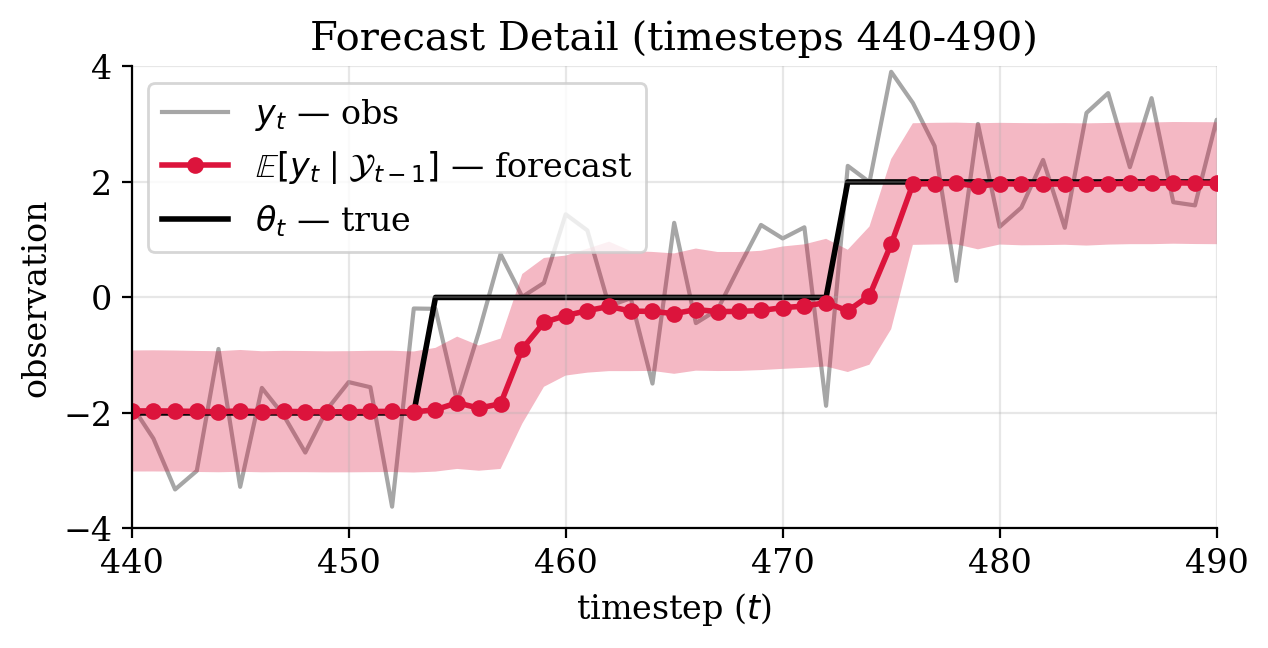

In [19]:
# Region 2: timesteps 440-490 (cleaner region)
plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.3, linewidth=0)

label_mean = r"$\mathbb{E}[y_{t} \mid {\cal Y}_{t-1}]$ — forecast"
plt.plot(obs, c="gray", alpha=0.7, label="$y_t$ — obs", zorder=0)
plt.plot(hist_forecast["mean"], c="crimson", linewidth=2, label=label_mean, marker="o", markersize=5)
plt.plot(means.at[states].get(), c="black", zorder=1, linewidth=2, label=r"$\theta_t$ — true")

plt.legend()
plt.xlim(440, 490)
plt.ylim(-4, 4)
plt.xlabel("timestep ($t$)")
plt.ylabel("observation")
plt.title("Forecast Detail (timesteps 440-490)")
plt.grid(alpha=0.3)

## Summary

This notebook demonstrates the streaming HMM implementation from the `streaming_hmm` module. 

Key results:
1. **Mean Estimation**: The algorithm successfully learns the mean parameters for each regime online
2. **Regime Detection**: The inferred regimes closely track the true latent states
3. **Forecasting**: One-step-ahead forecasts are accurate, with uncertainty bands capturing observation noise
4. **Stability**: Particle weights remain well-distributed (minimum weight > 0)

The modular implementation makes it easy to:
- Adjust the number of particles
- Modify initial priors
- Apply to different datasets
- Extend with additional features